In [5]:
# -----------------------------
# Download dataset
# -----------------------------

import gdown
import zipfile
import os

# https://drive.google.com/file/d/1-ko0giZe5ynkAA3EdJCaap7Mrdqr5P55/view?usp=sharing

# Google Drive file ID (Extracted from the URL)
file_id = "1-ko0giZe5ynkAA3EdJCaap7Mrdqr5P55"

# Destination file name
output_zip = "pictures.zip"

# Downloading the file from Google Drive
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_zip, quiet=False)

# Extracting the zip file
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall("pictures")  # Extracting to 'Clips' folder

# Removing the zip file after extraction
os.remove(output_zip)

print("Download and extraction complete!")


Downloading...
From (original): https://drive.google.com/uc?id=1-ko0giZe5ynkAA3EdJCaap7Mrdqr5P55
From (redirected): https://drive.google.com/uc?id=1-ko0giZe5ynkAA3EdJCaap7Mrdqr5P55&confirm=t&uuid=adef90a9-2f57-41dd-8d7a-542491409982
To: /content/pictures.zip
100%|██████████| 108M/108M [00:00<00:00, 220MB/s] 


Download and extraction complete!


In [17]:
# -----------------------------
# 1. LIBRARIES & CONFIG
# -----------------------------
import os, glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.transforms.functional import to_pil_image
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Subject Splits
train_subjects = [f"S{str(i).zfill(3)}" for i in range(1, 59)]
val_subjects = [f"S{str(i).zfill(3)}" for i in range(59, 62)]
test_subjects = [f"S{str(i).zfill(3)}" for i in range(62, 69)]

# Labels
EXPR_LABELS = {'Neutral': 0, 'Posed Pain': 1, 'Algometer Pain': 2, 'Laser Pain': 3}
IDX_TO_LABEL = {v: k for k, v in EXPR_LABELS.items()}

# Hyperparams
DATA_ROOT = "/content/pictures"
IMG_SIZE = 224
SEQ_LEN = 20
BATCH_SIZE = 4
EPOCHS = 40
LR = 1e-4
PATIENCE = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.95, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [18]:
# -----------------------------
# 2. Dataset + Loss + Positional Encoding
# -----------------------------

class PainSequenceDataset(Dataset):
    def __init__(self, subject_ids, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        for subject in subject_ids:
            subject_path = os.path.join(root_dir, subject)
            for expr, label in EXPR_LABELS.items():
                expr_path = os.path.join(subject_path, expr, "Colour frames")
                if os.path.exists(expr_path):
                    frame_files = sorted([
                        os.path.join(expr_path, f)
                        for f in os.listdir(expr_path) if f.endswith(".jpg")
                    ])
                    if len(frame_files) == SEQ_LEN:
                        self.samples.append((frame_files, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_paths, label = self.samples[idx]
        frames = [self.transform(Image.open(fp).convert('RGB')) for fp in frame_paths]
        return torch.stack(frames), label


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=SEQ_LEN):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position.float() * div_term)
        pe[:, 1::2] = torch.cos(position.float() * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)


class FocalLoss(nn.Module):
    def __init__(self, weights=None, gamma=2, reduction='mean'):
        super().__init__()
        self.weights = weights
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weights, reduction='none', label_smoothing=0.1)
        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss
        return loss.mean() if self.reduction == 'mean' else loss.sum()


In [19]:
# -----------------------------
# 3. CUSTOM TRANSFORMER ENCODER LAYER
# -----------------------------

class CustomTransformerEncoderLayer(nn.TransformerEncoderLayer):
    def forward(self, src, src_mask=None, src_key_padding_mask=None, is_causal=False):
        attn_output, attn_weights = self.self_attn(
            src, src, src,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False,
            is_causal=is_causal    # pass is_causal if self_attn supports it
        )
        src = src + self.dropout1(attn_output)
        src = self.norm1(src)
        ff_output = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(ff_output)
        src = self.norm2(src)
        return src, attn_weights



In [20]:
# -----------------------------
# MODEL: CNN + LSTM + Transformer (with attention return)
# -----------------------------

class HybridPainClassifier(nn.Module):
    def __init__(self, cnn_output_dim=1280, lstm_hidden=256, nhead=4, num_layers=1, num_classes=4):
        super().__init__()

        # Pretrained CNN Backbone (MobileNetV2)
        mobilenet = models.mobilenet_v2(pretrained=True)
        self.cnn = mobilenet.features

        # Freeze early layers
        for i, block in enumerate(self.cnn.children()):
            if i < 5:
                for param in block.parameters():
                    param.requires_grad = False

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()

        # LSTM to model short-term frame dependencies
        self.lstm = nn.LSTM(
            input_size=cnn_output_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True  # Gives output size = 2 * hidden
        )

        # Positional Encoding before Transformer
        self.pos_encoding = PositionalEncoding(d_model=lstm_hidden * 2)

        # Custom Transformer Encoder that returns attention weights
        encoder_layer = CustomTransformerEncoderLayer(
            d_model=lstm_hidden * 2,
            nhead=nhead,
            batch_first=True,
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(lstm_hidden * 2, num_classes)
        )

    def forward(self, x):  # x: (B, T, C, H, W)
        B, T, C, H, W = x.size()

        # CNN Feature extraction
        x = x.view(B * T, C, H, W)
        x = self.cnn(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = x.view(B, T, -1)  # shape: (B, T, cnn_output_dim)

        # LSTM temporal modeling
        lstm_out, _ = self.lstm(x)  # shape: (B, T, 2*lstm_hidden)

        # Transformer encoding
        x = self.pos_encoding(lstm_out)
        x, attn_weights = self.transformer(x)  # Custom layer returns attention weights

        # Mean pooling across time
        x = x.mean(dim=1)

        # Final classification
        out = self.classifier(x)

        return out, attn_weights  # Return both prediction and attention


In [21]:
# -----------------------------
# 5. Data Loaders & Setup
# -----------------------------

# Datasets and DataLoaders
train_dataset = PainSequenceDataset(train_subjects, DATA_ROOT, transform=train_transform)
val_dataset = PainSequenceDataset(val_subjects, DATA_ROOT, transform=val_transform)
test_dataset = PainSequenceDataset(test_subjects, DATA_ROOT, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Initialize model, loss, optimizer
model = HybridPainClassifier().to(device)
weights = torch.tensor([1.0, 1.0, 2.0, 1.0]).to(device)  # Emphasize Algometer
criterion = FocalLoss(weights=weights)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

train_acc_history, val_acc_history = [], []
best_val_acc = 0
wait = 0
best_model_wts = None


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [22]:
# -----------------------------
# 6. Training Loop (with early stopping & checkpointing)
# -----------------------------

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct = 0, 0
    for clips, labels in train_loader:
        clips, labels = clips.to(device), labels.to(device)
        outputs, _ = model(clips)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * clips.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = correct / len(train_dataset)

    model.eval()
    val_correct = 0
    with torch.no_grad():
        for clips, labels in val_loader:
            clips, labels = clips.to(device), labels.to(device)
            outputs, _ = model(clips)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_acc = val_correct / len(val_dataset)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {total_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")
    torch.save(model.state_dict(), f"checkpoint_epoch_{epoch+1}.pth")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        wait = 0
        best_model_wts = model.state_dict()
    else:
        wait += 1
        if wait >= PATIENCE:
            print("⏹️ Early stopping triggered.")
            break

if best_model_wts:
    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), "hybrid_cnn_lstm_transformer_best.pth")
    print("✅ Best model saved to hybrid_cnn_lstm_transformer_best.pth")


Epoch [1/40] Loss: 287.1396 | Train Acc: 26.11% | Val Acc: 25.00%
Epoch [2/40] Loss: 224.9122 | Train Acc: 41.15% | Val Acc: 25.00%
Epoch [3/40] Loss: 213.1827 | Train Acc: 40.71% | Val Acc: 66.67%
Epoch [4/40] Loss: 202.4095 | Train Acc: 42.48% | Val Acc: 66.67%
Epoch [5/40] Loss: 198.1087 | Train Acc: 45.58% | Val Acc: 66.67%
Epoch [6/40] Loss: 179.4615 | Train Acc: 50.00% | Val Acc: 41.67%
Epoch [7/40] Loss: 145.5231 | Train Acc: 57.96% | Val Acc: 41.67%
Epoch [8/40] Loss: 149.3886 | Train Acc: 61.06% | Val Acc: 41.67%
Epoch [9/40] Loss: 129.9679 | Train Acc: 66.81% | Val Acc: 58.33%
Epoch [10/40] Loss: 159.1854 | Train Acc: 61.50% | Val Acc: 50.00%
Epoch [11/40] Loss: 117.6171 | Train Acc: 67.70% | Val Acc: 50.00%
Epoch [12/40] Loss: 136.9298 | Train Acc: 61.50% | Val Acc: 41.67%
Epoch [13/40] Loss: 110.9938 | Train Acc: 68.14% | Val Acc: 66.67%
⏹️ Early stopping triggered.
✅ Best model saved to hybrid_cnn_lstm_transformer_best.pth


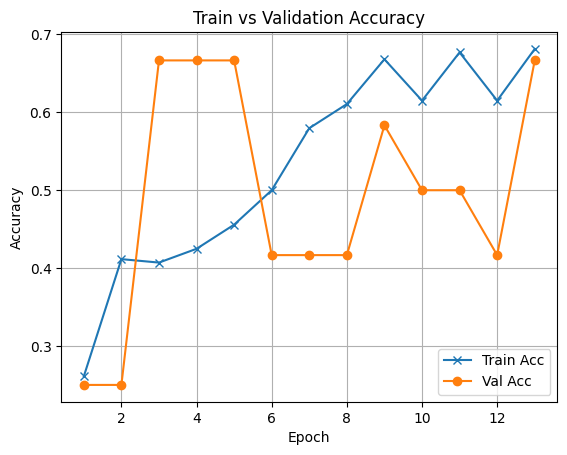

🧪 Final Test Accuracy: 50.00%


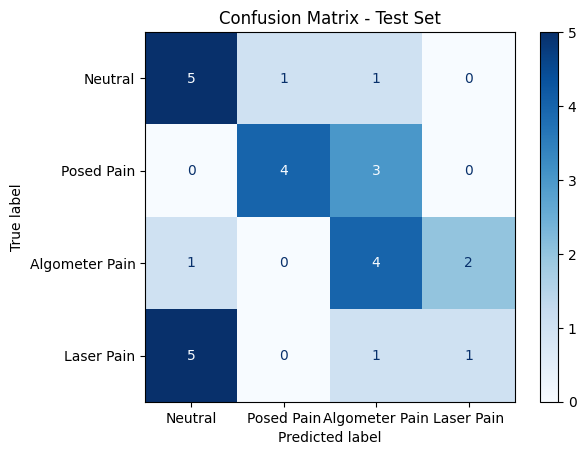

In [23]:
# -----------------------------
# 7. Accuracy Plot + Final Test Evaluation
# -----------------------------

# Accuracy Plot
plt.plot(range(1, len(train_acc_history)+1), train_acc_history, label='Train Acc', marker='x')
plt.plot(range(1, len(val_acc_history)+1), val_acc_history, label='Val Acc', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Final test accuracy
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for clips, labels in test_loader:
        clips, labels = clips.to(device), labels.to(device)
        outputs, _ = model(clips)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

acc = sum([p == t for p, t in zip(all_preds, all_labels)]) / len(all_preds)
print(f"🧪 Final Test Accuracy: {acc*100:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(EXPR_LABELS.keys()))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()


TypeError: unsupported format string passed to numpy.ndarray.__format__

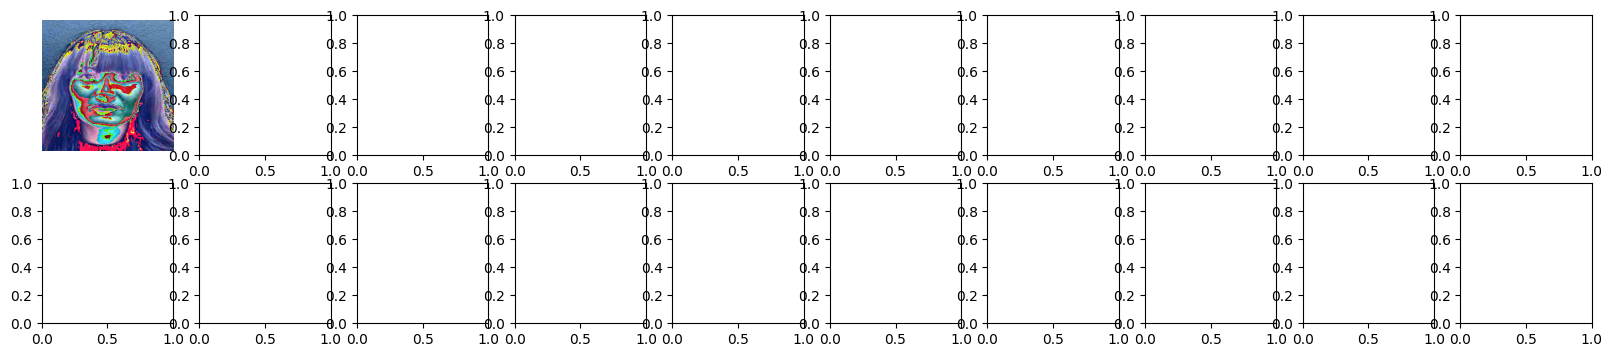

In [24]:
# -----------------------------
# 8. Attention Map Visualization Function
# -----------------------------

def visualize_attention_on_frames(model, clip_folder, transform):
    model.eval()
    clip_paths = sorted(glob.glob(os.path.join(clip_folder, "*.jpg")))
    frames = [transform(Image.open(fp).convert('RGB')) for fp in clip_paths]
    clip_tensor = torch.stack(frames).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs, attn = model(clip_tensor)

    attn_scores = attn.squeeze(0).mean(dim=0).cpu().numpy()  # (20,)

    fig, axs = plt.subplots(2, 10, figsize=(20, 4))
    axs = axs.flatten()

    for i in range(20):
        img = to_pil_image(frames[i].cpu())
        axs[i].imshow(img)
        axs[i].axis('off')
        axs[i].set_title(f"A: {attn_scores[i]:.2f}", fontsize=8)
        axs[i].patch.set_edgecolor('red')
        axs[i].patch.set_linewidth(attn_scores[i] * 5)

    plt.suptitle("Attention Map Across Frames", fontsize=16)
    plt.tight_layout()
    plt.show()

clip_path = "/content/pictures/S062/Laser Pain/Colour frames"
visualize_attention_on_frames(model, clip_path, val_transform)
